In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
#from imblearn.under_sampling import RandomUnderSampler
import pandas as pd
import xgboost
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

In [2]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
data_path = 'C:\GaTech\MS-CSE\ISYE 6740\WiFOP\data\\final datasets\ca_5km_daily_panel_2020_2023_6_9 1\ca_5km_daily_panel_2020_2023_6_9.csv'
data = pd.read_csv(data_path, sep=',')
data.head()

,date,grid_id,fire_today,lon,lat,w_lat,w_lon,T2M,PS,WS10M,...,pct_Pasture/Hay,pct_Cultivated Crops,pct_Woody Wetlands,pct_Emergent Herbaceous Wetlands,T2M_3d_mean,RH2M_3d_min,WS10M_3d_max,PRECTOT_7d_sum,fires_last_7d,fires_last_14d
0,2020-06-01,CA5K_00000,0,-124.350397,40.266353,40.5,-124.375,12.43,100.06,5.77,...,0.0,0.0,0.0,0.0,12.430000,90.21,5.77,0.08,NaN,NaN
1,2020-06-02,CA5K_00000,0,-124.350397,40.266353,40.5,-124.375,12.96,100.23,6.59,...,0.0,0.0,0.0,0.0,12.695000,89.99,6.59,0.08,0.0,0.0
2,2020-06-03,CA5K_00000,0,-124.350397,40.266353,40.5,-124.375,12.96,100.23,7.16,...,0.0,0.0,0.0,0.0,12.783333,89.99,7.16,0.08,0.0,0.0
3,2020-06-04,CA5K_00000,0,-124.350397,40.266353,40.5,-124.375,12.57,99.92,8.24,...,0.0,0.0,0.0,0.0,12.830000,89.65,8.24,0.08,0.0,0.0
4,2020-06-05,CA5K_00000,0,-124.350397,40.266353,40.5,-124.375,12.04,99.44,5.62,...,0.0,0.0,0.0,0.0,12.523333,89.65,8.24,0.18,0.0,0.0


In [4]:
def median_imputation(df):
    for col in df.columns:
        if col == 'grid_id' or col == 'date':
            continue
        df[col] = df[col].fillna(df[col].median())
    return df

In [5]:
#temporal train and test split

data['date'] = pd.to_datetime(data['date'], errors='raise')
data['year'] = data['date'].dt.year
train_mask = data['year'].isin([2020, 2021, 2022])
test_mask = data['year'] == 2023

In [6]:
train_df = data.loc[train_mask].copy()
test_df = data.loc[test_mask].copy()

In [7]:
#drop the grid id, date, w_lat, w_lon, n_lon, n_lat, year
X_train = train_df.drop(columns=['date', 'grid_id', 'w_lat', 'w_lon', 'n_lat', 'n_lon', 'year']).reset_index(drop=True)

X_test = test_df.drop(columns=['date', 'grid_id', 'w_lat', 'w_lon', 'n_lat', 'n_lon', 'year']).reset_index(drop=True)

In [8]:
y_train = X_train.pop('fire_today')
y_test = X_test.pop('fire_today')

In [9]:
#X_train, X_test, y_train, y_test = train_test_split(X_, y, stratify=y, test_size=0.20, random_state=42)

In [10]:
X_train, X_test = median_imputation(X_train), median_imputation(X_test)

In [11]:
#perform feature selection with xgboost
feature_selector = xgboost.XGBClassifier(device='cuda', n_estimators=400, random_state=42)
feature_selector.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [12]:
importances = feature_selector.feature_importances_

In [13]:
top_k = list(pd.DataFrame({'Features': X_train.columns, 'Importances': importances}).sort_values(by='Importances', ascending=False).iloc[:20, 0])

In [14]:
top_k

['ndvi_interp',
 'ndvi_21d_mean',
 'ndvi_drop',
 'fires_last_14d',
 'lat',
 'ndvi',
 'T2M_3d_mean',
 'fires_last_7d',
 'RH2M',
 'PS',
 'ndvi_7d_mean',
 'RH2M_3d_min',
 'lon',
 'pct_Developed, Low Intensity',
 'PRECTOT_7d_sum',
 'WS10M_3d_max',
 'T2M',
 'pct_Barren Land (Rock/Sand/Clay)',
 'pct_Evergreen Forest',
 'WS10M']

In [15]:
X_train_selected = X_train[top_k]
X_test_selected = X_test[top_k]

In [16]:
X_train_selected.shape

(6185766, 20)

In [17]:
scaler2 = StandardScaler()
X_train_selected_scaled = scaler2.fit_transform(X_train_selected)
X_test_selected_scaled = scaler2.transform(X_test_selected)

In [18]:
class Model(tf.keras.Model):
    def __init__(self, input_dimension, neurons, num_classes):
        super().__init__()

        #Convolutional Layer
        self.conv1 = tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')
        self.batch1 = tf.keras.layers.BatchNormalization()
        self.maxpool1 = tf.keras.layers.MaxPool1D(3)

        #Convolutional Layer
        self.conv2 = tf.keras.layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')
        self.batch2 = tf.keras.layers.BatchNormalization()
        self.maxpool2 = tf.keras.layers.MaxPool1D(3)

        #Flatten Layer
        self.flatten = tf.keras.layers.Flatten()

        #Dense Layer (hidden layer)
        self.dense = tf.keras.layers.Dense(units=neurons, activation='relu')
        self.batch3 = tf.keras.layers.BatchNormalization()
        self.output_layer = tf.keras.layers.Dense(units=num_classes, activation='sigmoid')

    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.batch1(x)
        x = self.maxpool1(x)

        x = self.flatten(x)
        x = self.dense(x)
        x = self.batch3(x)
        output = self.output_layer(x)

        return output


In [19]:
n_features = len(top_k)
model = Model(input_dimension=n_features, neurons=64, num_classes=1)
model.build(input_shape=(None, n_features, 1))
model.compile(loss=tf.keras.losses.BinaryCrossentropy(), optimizer='Adam', metrics=['accuracy'])

In [20]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             multiple                  128       
                                                                 
 batch_normalization (BatchN  multiple                 128       
 ormalization)                                                   
                                                                 
 max_pooling1d (MaxPooling1D  multiple                 0         
 )                                                               
                                                                 
 conv1d_1 (Conv1D)           multiple                  0 (unused)
                                                                 
 batch_normalization_1 (Batc  multiple                 0 (unused)
 hNormalization)                                                 
                                                             

In [21]:
X_train_cnn = X_train_selected_scaled.reshape(-1, n_features, 1)
X_test_cnn = X_test_selected_scaled.reshape(-1, n_features, 1)

In [22]:
num_classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=num_classes, y=y_train)
cw_dict = dict(zip(num_classes, weights))

In [23]:
cw_dict

{0: 0.5012184135780392, 1: 205.68484405134004}

In [24]:
cb = [EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]

history = model.fit(X_train_cnn, y_train, batch_size=100, epochs=20, verbose=2, validation_split=0.1, class_weight=cw_dict)

Epoch 1/20
55672/55672 - 163s - loss: 0.5298 - accuracy: 0.7298 - val_loss: 0.3011 - val_accuracy: 0.9663 - 163s/epoch - 3ms/step
Epoch 2/20
55672/55672 - 155s - loss: 0.5091 - accuracy: 0.7428 - val_loss: 0.3265 - val_accuracy: 0.9489 - 155s/epoch - 3ms/step
Epoch 3/20
55672/55672 - 158s - loss: 0.5034 - accuracy: 0.7462 - val_loss: 0.1591 - val_accuracy: 0.9946 - 158s/epoch - 3ms/step
Epoch 4/20
55672/55672 - 166s - loss: 0.4992 - accuracy: 0.7464 - val_loss: 0.1758 - val_accuracy: 0.9934 - 166s/epoch - 3ms/step
Epoch 5/20
55672/55672 - 162s - loss: 0.4984 - accuracy: 0.7457 - val_loss: 0.1363 - val_accuracy: 0.9977 - 162s/epoch - 3ms/step
Epoch 6/20
55672/55672 - 159s - loss: 0.4939 - accuracy: 0.7486 - val_loss: 0.2636 - val_accuracy: 0.9614 - 159s/epoch - 3ms/step
Epoch 7/20
55672/55672 - 157s - loss: 0.4930 - accuracy: 0.7486 - val_loss: 0.1971 - val_accuracy: 0.9921 - 157s/epoch - 3ms/step
Epoch 8/20
55672/55672 - 159s - loss: 0.4911 - accuracy: 0.7499 - val_loss: 0.1500 - val_a

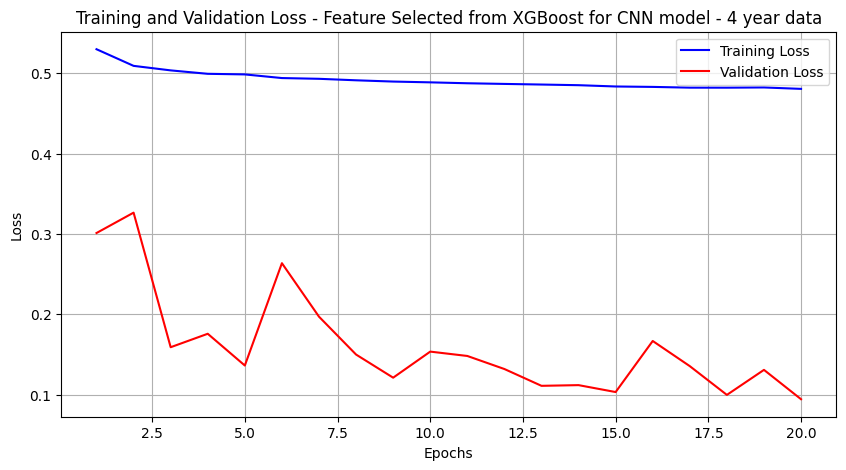

In [32]:
import matplotlib.pyplot as plt

epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, history.history['loss'], 'b', label='Training Loss')
plt.plot(epochs, history.history['val_loss'], 'r', label='Validation Loss')
plt.title('Training and Validation Loss - Feature Selected from XGBoost for CNN model - 4 year data')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

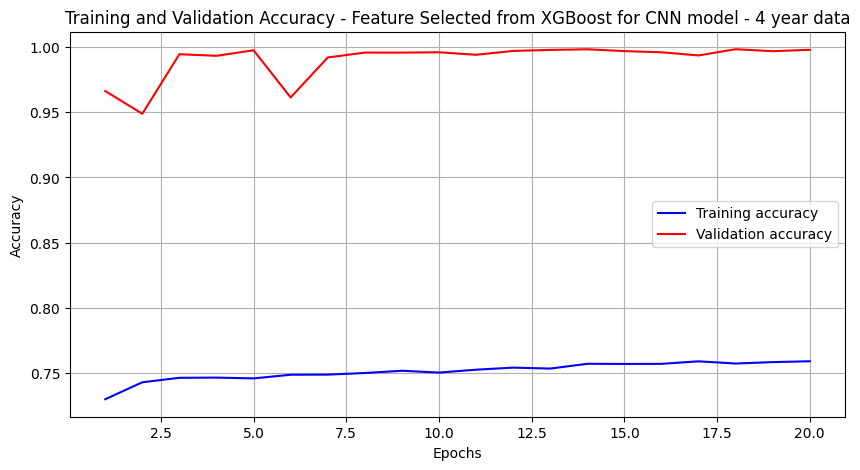

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(epochs, history.history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history.history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy - Feature Selected from XGBoost for CNN model - 4 year data')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
predictions = model.predict(X_test_cnn)
y_pred = np.argmax(predictions, axis=1)

64436/64436 [==============================] - 60s 932us/step


In [28]:
print(precision_score(y_test, y_pred, average='weighted', zero_division=0))
print(recall_score(y_test, y_pred, average='weighted', zero_division=0))
print(f1_score(y_test, y_pred, average='weighted', zero_division=0))

0.9936896699253067
0.9968398416622937
0.9952622630947685


In [29]:
clr = classification_report(y_test, y_pred, zero_division=0.0, output_dict=True)

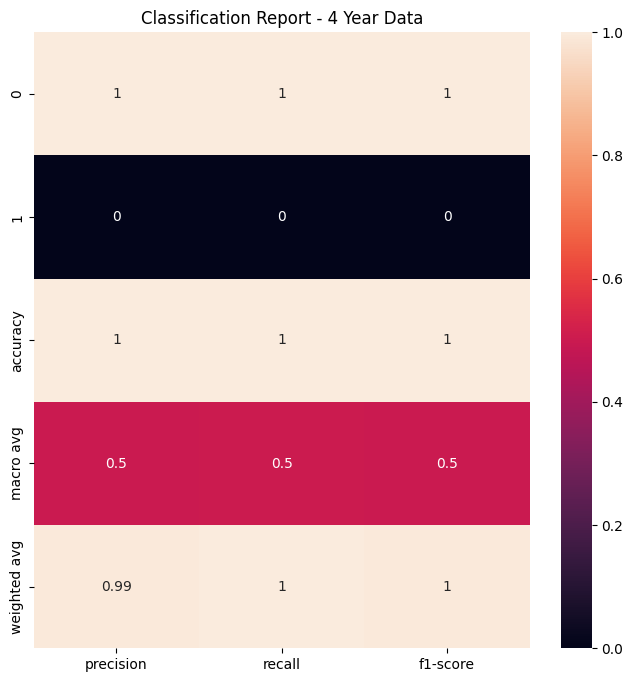

In [30]:
import seaborn as sns

df_clr = pd.DataFrame(clr).transpose()
plt.figure(figsize=(8,8))
sns.heatmap(df_clr[['precision', 'recall', 'f1-score']], annot=True)
plt.title('Classification Report - 4 Year Data')
plt.show()